### Imports, Connection, and Global Style

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [3]:
# Global Style

# Seaborn
sns.set_theme(
    style="whitegrid",
    palette="muted",
    font_scale=1.1,
)

# Matplotlib
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [6]:
# Connecting to DuckDB

con = duckdb.connect("../data/processed/recipeiq.duckdb", read_only=True)
print("Connected to RecipeIQ warehouse ✓")

recipe_count = con.execute("SELECT COUNT(*) FROM recipes").fetchone()[0]
review_count = con.execute("SELECT COUNT(*) FROM reviews").fetchone()[0]

print(f"Recipes: {recipe_count:,} | Reviews: {review_count:,}")

Connected to RecipeIQ warehouse ✓
Recipes: 522,517 | Reviews: 1,401,768


### Top 15 Categories — Horizontal Bar Chart

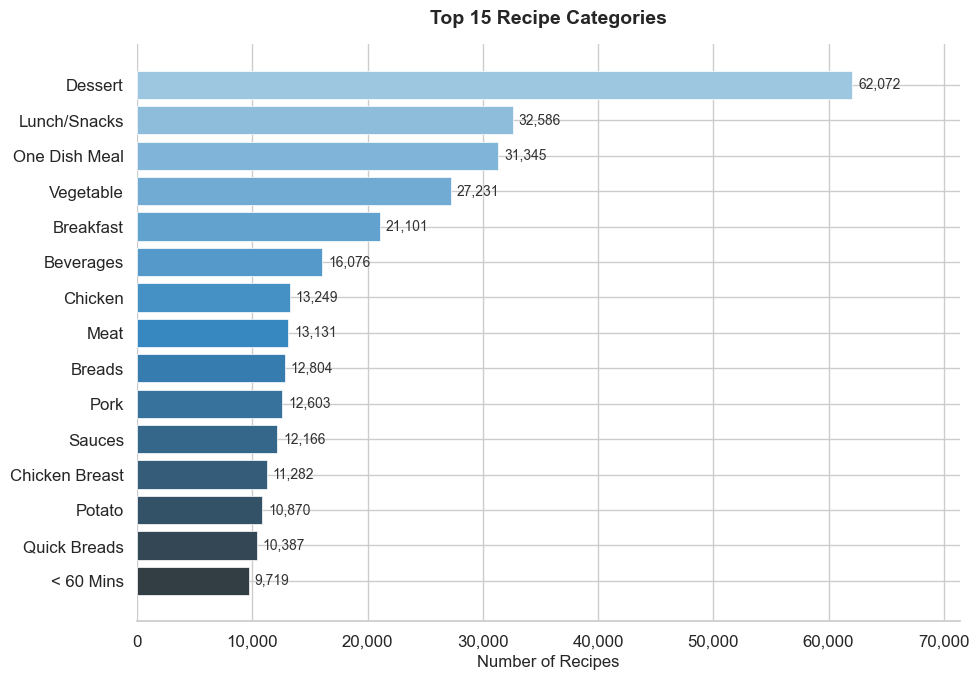

In [13]:
# Query
df = con.execute("""
    SELECT
        RecipeCategory,
        COUNT(*) AS recipe_count
    FROM recipes
    WHERE RecipeCategory IS NOT NULL
    GROUP BY RecipeCategory
    ORDER BY recipe_count DESC
    LIMIT 15
""").fetchdf()

# Chart
fig, ax = plt.subplots(figsize=(10, 7))

# Horizontal Bar - Categories on y and counts on x-axis
bars = ax.barh(
    df["RecipeCategory"],
    df["recipe_count"],
    color = sns.color_palette("Blues_d", len(df)),
    edgecolor = "white",
    linewidth = 0.5,
)

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize = 10,
        color = "#333333"
    )

ax.set_xlabel("Number of Recipes")
ax.set_title("Top 15 Recipe Categories", fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(right=df["recipe_count"].max() * 1.15)

sns.despine(left=True)

plt.tight_layout()
plt.savefig("../data/processed/figures/01_top_categories.png", bbox_inches="tight")
plt.show()

### Rating Distribution — Histogram with KDE

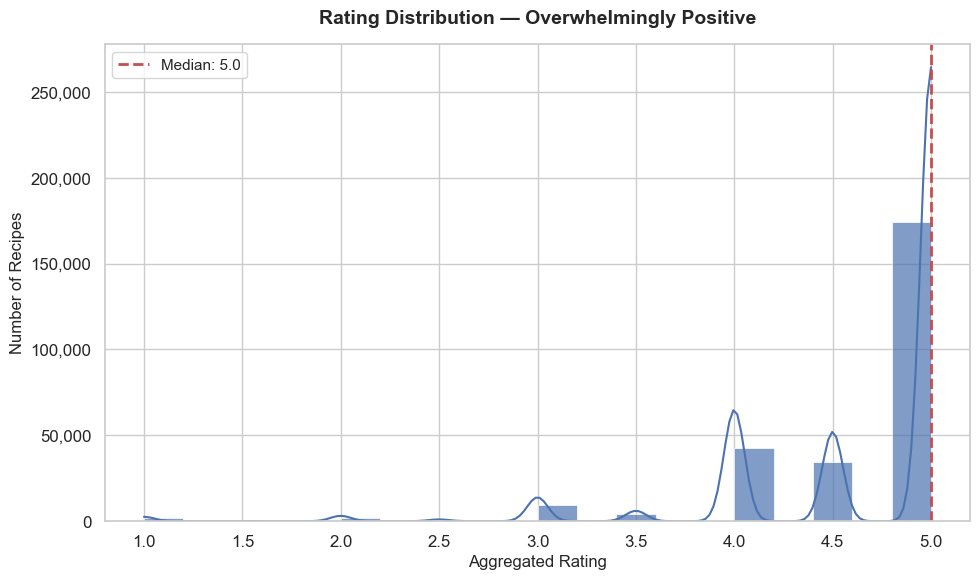

Total rated recipes: 269,294
Mean: 4.63
Median: 5.0
% rated 5.0: 64.8%


In [ ]:
# Query
df_ratings = con.execute("""
    SELECT AggregatedRating
    FROM recipes
    WHERE AggregatedRating IS NOT NULL
""").fetchdf()

# Chart
fig, ax = plt.subplots()

sns.histplot(
    data=df_ratings,
    x="AggregatedRating",
    bins=20,                    # 20 bars across the rating range
    kde=True,                   # Add the smooth density curve
    color="#4C72B0",            # Muted blue
    edgecolor="white",
    linewidth=0.5,
    alpha=0.7,                  # Slightly transparent bars
    ax=ax,
)

# Adding a line for the median
median_rating = df_ratings["AggregatedRating"].median()
ax.axvline(
    median_rating,
    color="#C44E52",             # Red accent line
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_rating:.1f}",
)

ax.set_xlabel("Aggregated Rating")
ax.set_ylabel("Number of Recipes")
ax.set_title("Rating Distribution — Overwhelmingly Positive", fontweight="bold", pad=15)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../data/processed/figures/02_rating_distribution.png", bbox_inches="tight")
plt.show()

# Print stats below the chart
print(f"Total rated recipes: {len(df_ratings):,}")
print(f"Mean: {df_ratings['AggregatedRating'].mean():.2f}")
print(f"Median: {median_rating}")
print(f"% rated 5.0: {(df_ratings['AggregatedRating'] == 5.0).mean() * 100:.1f}%")

### Complexity vs Rating — Grouped Bar Chart

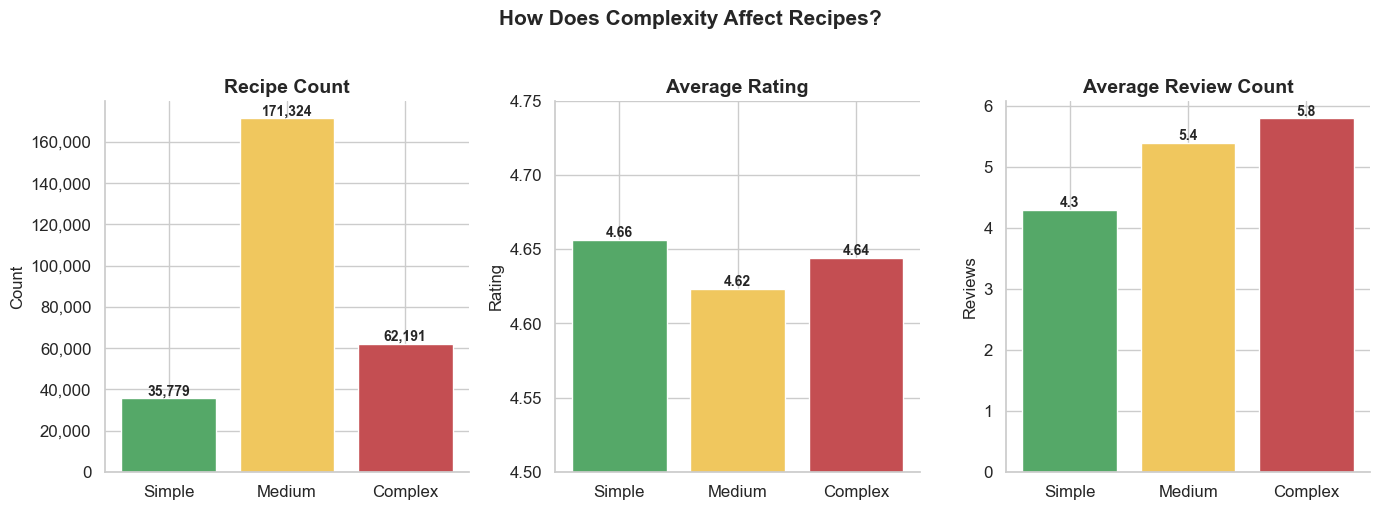

In [15]:
# QUERY
df_complexity = con.execute("""
    SELECT
        CASE complexity_score
            WHEN 1 THEN 'Simple'
            WHEN 2 THEN 'Medium'
            WHEN 3 THEN 'Complex'
        END AS difficulty,
        complexity_score,
        COUNT(*) AS recipe_count,
        ROUND(AVG(AggregatedRating), 3) AS avg_rating,
        ROUND(AVG(ReviewCount), 1) AS avg_reviews,
        ROUND(AVG(calories_per_serving), 0) AS avg_calories
    FROM recipes
    WHERE AggregatedRating IS NOT NULL
    GROUP BY complexity_score
    ORDER BY complexity_score
""").fetchdf()

#CHART - COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = ["#55A868", "#F0C75E", "#C44E52"]   # Green, gold, red

# Panel 1: Recipe count
axes[0].bar(df_complexity["difficulty"], df_complexity["recipe_count"], color=colors)
axes[0].set_title("Recipe Count", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Panel 2: Average rating
axes[1].bar(df_complexity["difficulty"], df_complexity["avg_rating"], color=colors)
axes[1].set_title("Average Rating", fontweight="bold")
axes[1].set_ylabel("Rating")
axes[1].set_ylim(4.5, 4.75)    # Zoom in — differences are small but significant

# Panel 3: Average reviews
axes[2].bar(df_complexity["difficulty"], df_complexity["avg_reviews"], color=colors)
axes[2].set_title("Average Review Count", fontweight="bold")
axes[2].set_ylabel("Reviews")

# Add value labels on top of each bar across all panels
for ax_i, col in zip(axes, ["recipe_count", "avg_rating", "avg_reviews"]):
    for j, val in enumerate(df_complexity[col]):
        fmt = f"{val:,.0f}" if col == "recipe_count" else f"{val:.2f}" if col == "avg_rating" else f"{val:.1f}"
        ax_i.text(j, val, fmt, ha="center", va="bottom", fontsize=10, fontweight="bold")

fig.suptitle(
    "How Does Complexity Affect Recipes?",
    fontsize=15, fontweight="bold", y=1.02,
)

sns.despine()
plt.tight_layout()
plt.savefig("../data/processed/figures/03_complexity_comparison.png", bbox_inches="tight")
plt.show()


### Nutrition Heatmap — Average Nutrients by Category

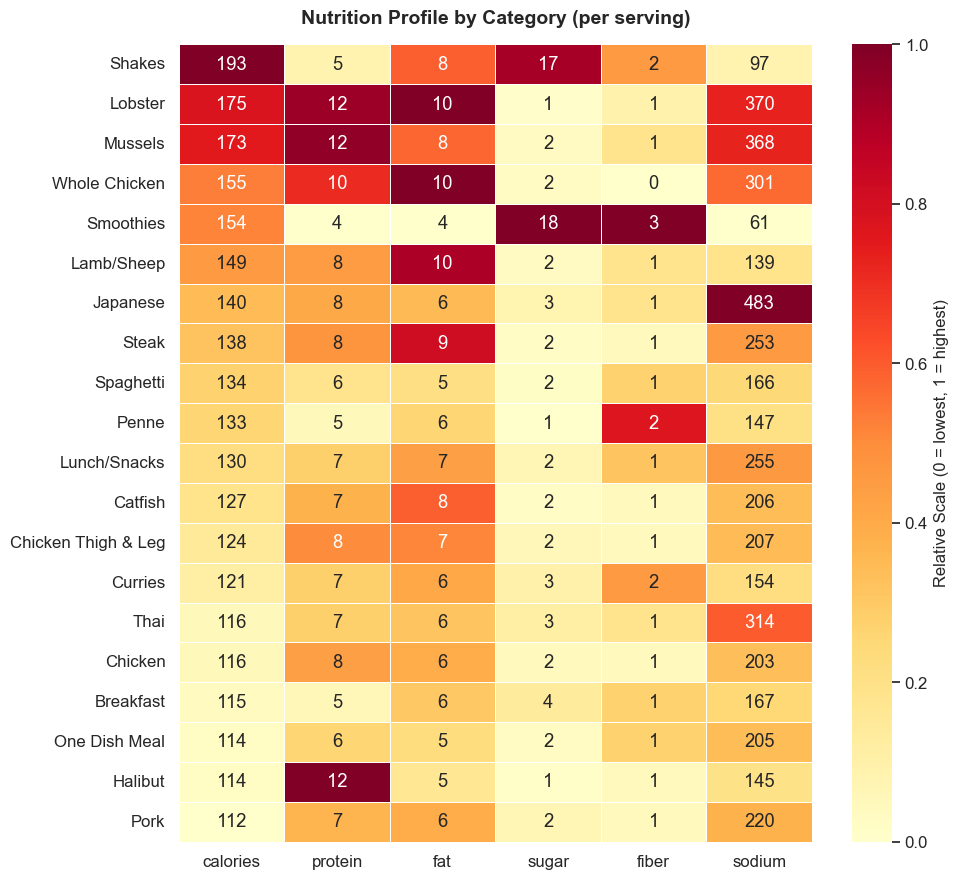

In [16]:
# QUERY
df_nutrition = con.execute("""
    SELECT
        RecipeCategory,
        ROUND(AVG(calories_per_serving), 0) AS calories,
        ROUND(AVG(protein_per_serving), 1) AS protein,
        ROUND(AVG(fat_per_serving), 1) AS fat,
        ROUND(AVG(sugar_per_serving), 1) AS sugar,
        ROUND(AVG(fiber_per_serving), 1) AS fiber,
        ROUND(AVG(sodium_per_serving), 0) AS sodium
    FROM recipes
    WHERE RecipeCategory IS NOT NULL
      AND calories_per_serving IS NOT NULL
      AND calories_per_serving < 2000
    GROUP BY RecipeCategory
    HAVING COUNT(*) >= 200
    ORDER BY calories DESC
    LIMIT 20
""").fetchdf()

# HEATMAP
heatmap_data = df_nutrition.set_index("RecipeCategory")

from sklearn.preprocessing import MinMaxScaler
normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns,
)

# CHART
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(
    normalized,
    annot=heatmap_data.values,        # Show ORIGINAL values in cells
    fmt=".0f",                         # Format annotations as integers
    cmap="YlOrRd",                     # Yellow → Orange → Red gradient
    linewidths=0.5,                    # White lines between cells
    linecolor="white",
    cbar_kws={"label": "Relative Scale (0 = lowest, 1 = highest)"},
    ax=ax,
)

ax.set_title("Nutrition Profile by Category (per serving)", fontweight="bold", pad=15)
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../data/processed/figures/04_nutrition_heatmap.png", bbox_inches="tight")
plt.show()

### ublishing Trends Over Time — Line Chart

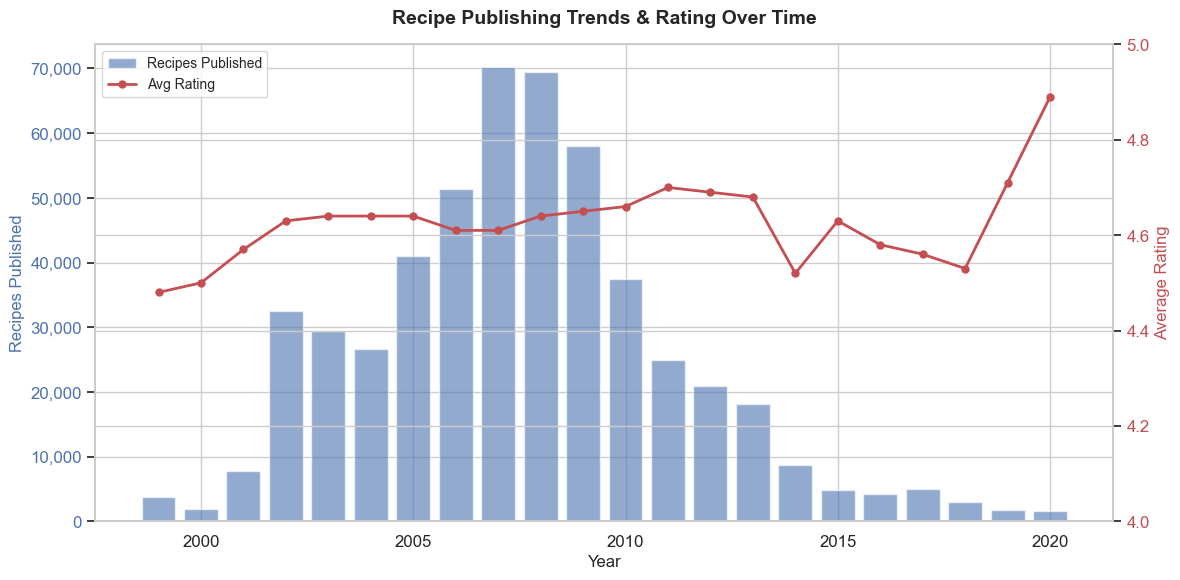

Peak year: 2007 with 70,204 recipes


In [17]:
# QUERY
df_trends = con.execute("""
    SELECT
        EXTRACT(YEAR FROM DatePublished) AS year,
        COUNT(*) AS recipes_published,
        ROUND(AVG(AggregatedRating), 2) AS avg_rating
    FROM recipes
    WHERE EXTRACT(YEAR FROM DatePublished) BETWEEN 1999 AND 2023
    GROUP BY year
    ORDER BY year
""").fetchdf()

# CHART
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis — recipe count (bars)
bars = ax1.bar(
    df_trends["year"],
    df_trends["recipes_published"],
    color="#4C72B0",
    alpha=0.6,
    label="Recipes Published",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Recipes Published", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Right axis — average rating (line)
ax2 = ax1.twinx()
ax2.plot(
    df_trends["year"],
    df_trends["avg_rating"],
    color="#C44E52",
    marker="o",
    markersize=5,
    linewidth=2,
    label="Avg Rating",
)
ax2.set_ylabel("Average Rating", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(4.0, 5.0)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.set_title("Recipe Publishing Trends & Rating Over Time", fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("../data/processed/figures/05_publishing_trends.png", bbox_inches="tight")
plt.show()

# Print peak year
peak = df_trends.loc[df_trends["recipes_published"].idxmax()]
print(f"Peak year: {int(peak['year'])} with {int(peak['recipes_published']):,} recipes")

### Review Length vs Rating — Box Plot

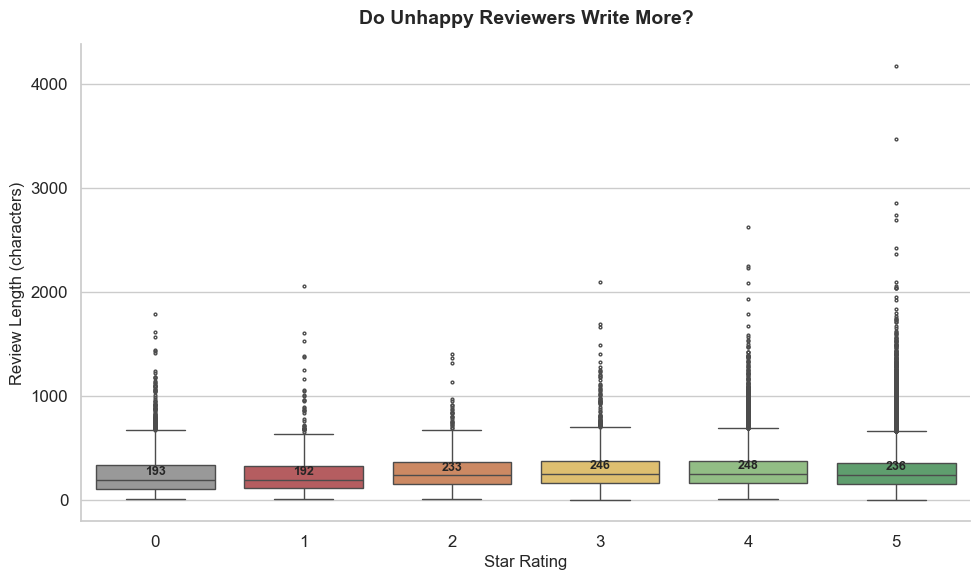

In [ ]:
# QUERY
# Sampling reviews to keep the chart responsive (1.4M points is too many)
df_reviews = con.execute("""
    SELECT
        Rating,
        review_length
    FROM reviews
    WHERE review_length IS NOT NULL
      AND review_length > 0
      AND review_length < 5000     -- Exclude extreme outliers
    USING SAMPLE 50000
""").fetchdf()

# CHART
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_reviews,
    x="Rating",
    y="review_length",
    hue="Rating",                # Assign hue explicitly (required in seaborn 0.14+)
    palette=["#999999", "#C44E52", "#DD8452", "#F0C75E", "#8DC77B", "#55A868"],  # 6 colors for 0-5 stars
    legend=False,                # x-axis already shows ratings, no legend needed
    fliersize=2,     # Make outlier dots small
    ax=ax,
)

ax.set_xlabel("Star Rating")
ax.set_ylabel("Review Length (characters)")
ax.set_title("Do Unhappy Reviewers Write More?", fontweight="bold", pad=15)

# Add median labels above each box
medians = df_reviews.groupby("Rating")["review_length"].median()
for i, (rating, median_val) in enumerate(medians.items()):
    ax.text(i, median_val + 50, f"{median_val:.0f}", ha="center", fontsize=9, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.savefig("../data/processed/figures/06_review_length_vs_rating.png", bbox_inches="tight")
plt.show()

### Ingredient Count Sweet Spot — Scatter with Trend

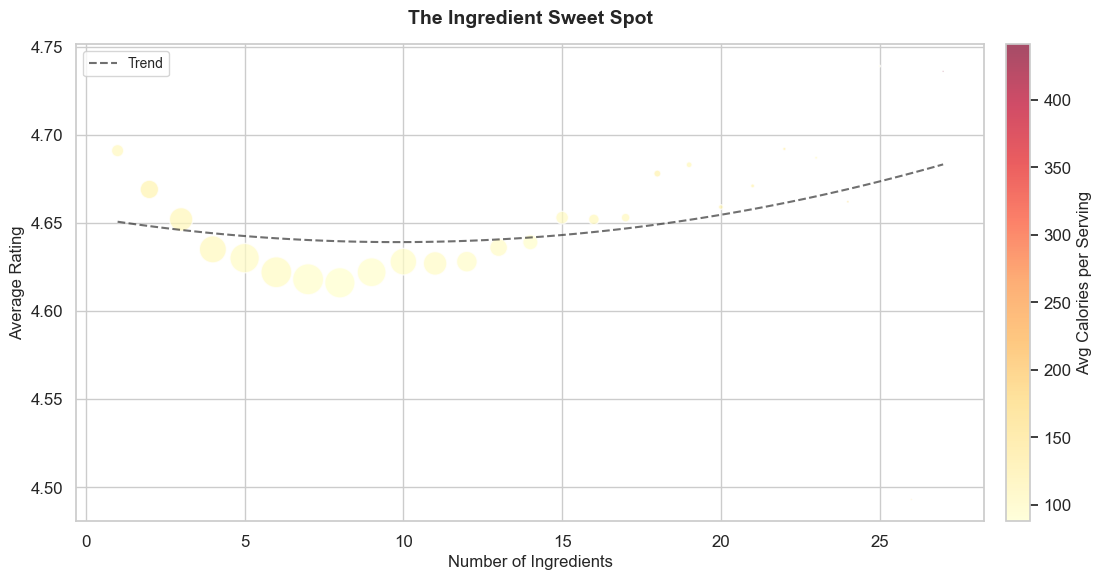

Sweet spot: 25 ingredients → 4.739 avg rating


In [20]:
# QUERY
df_ingredients = con.execute("""
    SELECT
        ingredient_count,
        COUNT(*) AS recipe_count,
        ROUND(AVG(AggregatedRating), 3) AS avg_rating,
        ROUND(AVG(calories_per_serving), 0) AS avg_calories
    FROM recipes
    WHERE ingredient_count IS NOT NULL
      AND AggregatedRating IS NOT NULL
      AND ingredient_count BETWEEN 1 AND 30
    GROUP BY ingredient_count
    HAVING COUNT(*) >= 50
    ORDER BY ingredient_count
""").fetchdf()

# CHART
fig, ax = plt.subplots(figsize=(12, 6))

# Bubble size = number of recipes (normalized to visible range)
sizes = (df_ingredients["recipe_count"] / df_ingredients["recipe_count"].max()) * 500

scatter = ax.scatter(
    df_ingredients["ingredient_count"],
    df_ingredients["avg_rating"],
    s=sizes,                            # Bubble size
    c=df_ingredients["avg_calories"],    # Color by calories
    cmap="YlOrRd",                      # Yellow = low cal, Red = high cal
    alpha=0.7,
    edgecolors="white",
    linewidth=1,
)

# Add a trend line
z = np.polyfit(df_ingredients["ingredient_count"], df_ingredients["avg_rating"], 2)
p = np.poly1d(z)
x_smooth = np.linspace(
    df_ingredients["ingredient_count"].min(),
    df_ingredients["ingredient_count"].max(),
    100,
)
ax.plot(x_smooth, p(x_smooth), "--", color="#333333", linewidth=1.5, alpha=0.7, label="Trend")

# Colorbar for calories
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Avg Calories per Serving")

ax.set_xlabel("Number of Ingredients")
ax.set_ylabel("Average Rating")
ax.set_title("The Ingredient Sweet Spot", fontweight="bold", pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../data/processed/figures/07_ingredient_sweet_spot.png", bbox_inches="tight")
plt.show()

# Find the sweet spot
best = df_ingredients.loc[df_ingredients["avg_rating"].idxmax()]
print(f"Sweet spot: {int(best['ingredient_count'])} ingredients → {best['avg_rating']:.3f} avg rating")
